In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import yfinance as yf 
from datetime import datetime

### 1.Data Collection

In [2]:
now = datetime.now()

start = datetime(now.year - 12, now.month, now.day)
end = datetime(now.year, now.month, now.day)
 
ticker = "BTC-USD"

df = yf.download(ticker, start, end)
df.shape
df.isna().sum()
#df.describe()
#df.dtypes
df


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2014-09-17,457.334015,468.174011,452.421997,465.864014,21056800
2014-09-18,424.440002,456.859985,413.104004,456.859985,34483200
2014-09-19,394.795990,427.834991,384.532013,424.102997,37919700
2014-09-20,408.903992,423.295990,389.882996,394.673004,36863600
2014-09-21,398.821014,412.425995,393.181000,408.084991,26580100
...,...,...,...,...,...
2026-01-18,93634.429688,95491.507812,93588.867188,95101.179688,20809781232
2026-01-19,92553.593750,93660.828125,92089.250000,93655.671875,39195241508


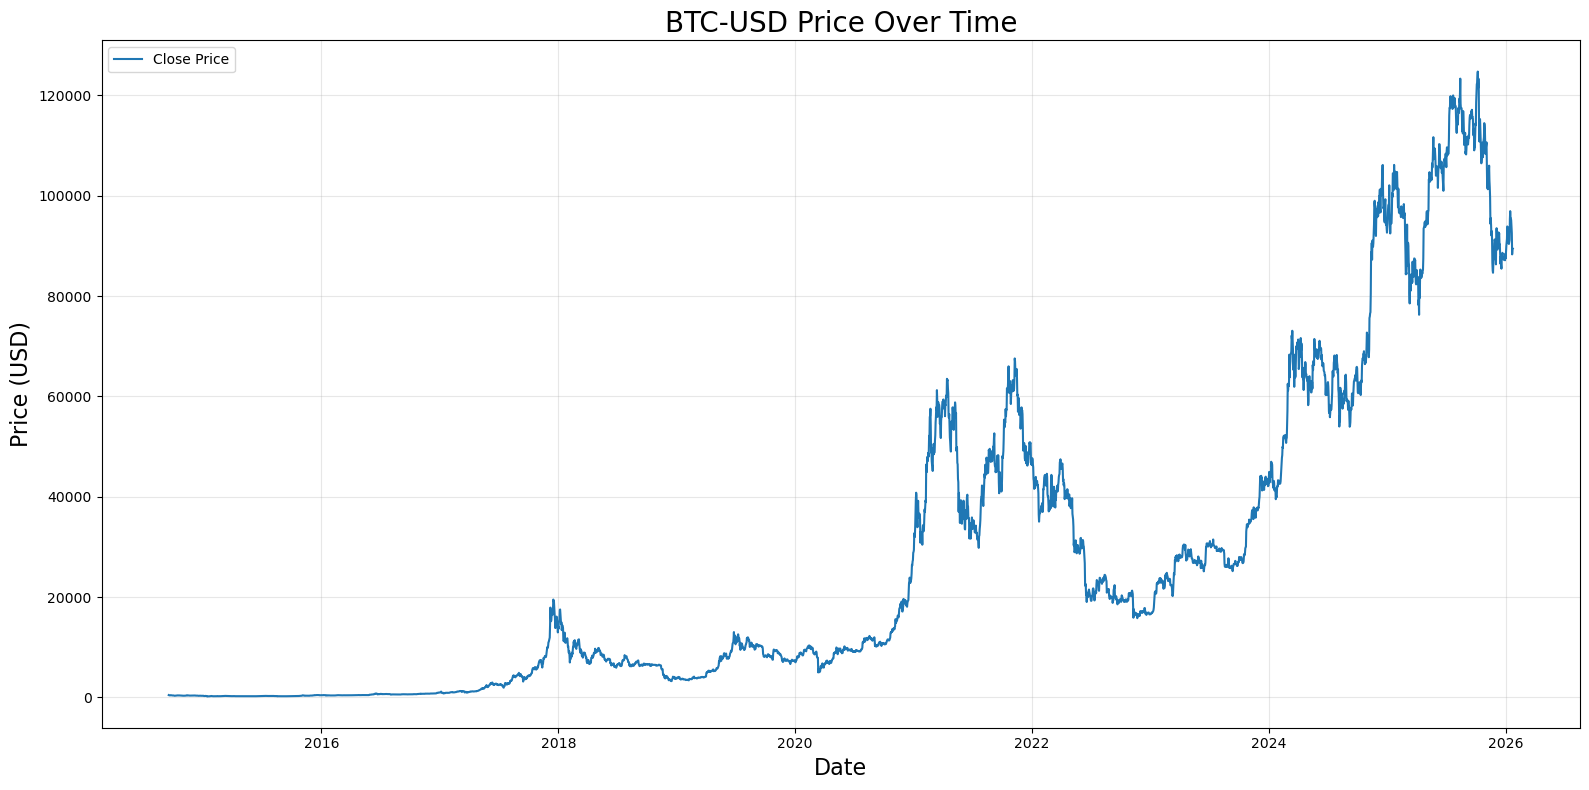

In [3]:


plt.figure(figsize=(16,8))
plt.plot(df.index, df["Close"], label="Close Price")
plt.title(f"{ticker} Price Over Time", fontsize=20)
plt.xlabel("Date", fontsize=16)
plt.ylabel("Price (USD)", fontsize=16)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()



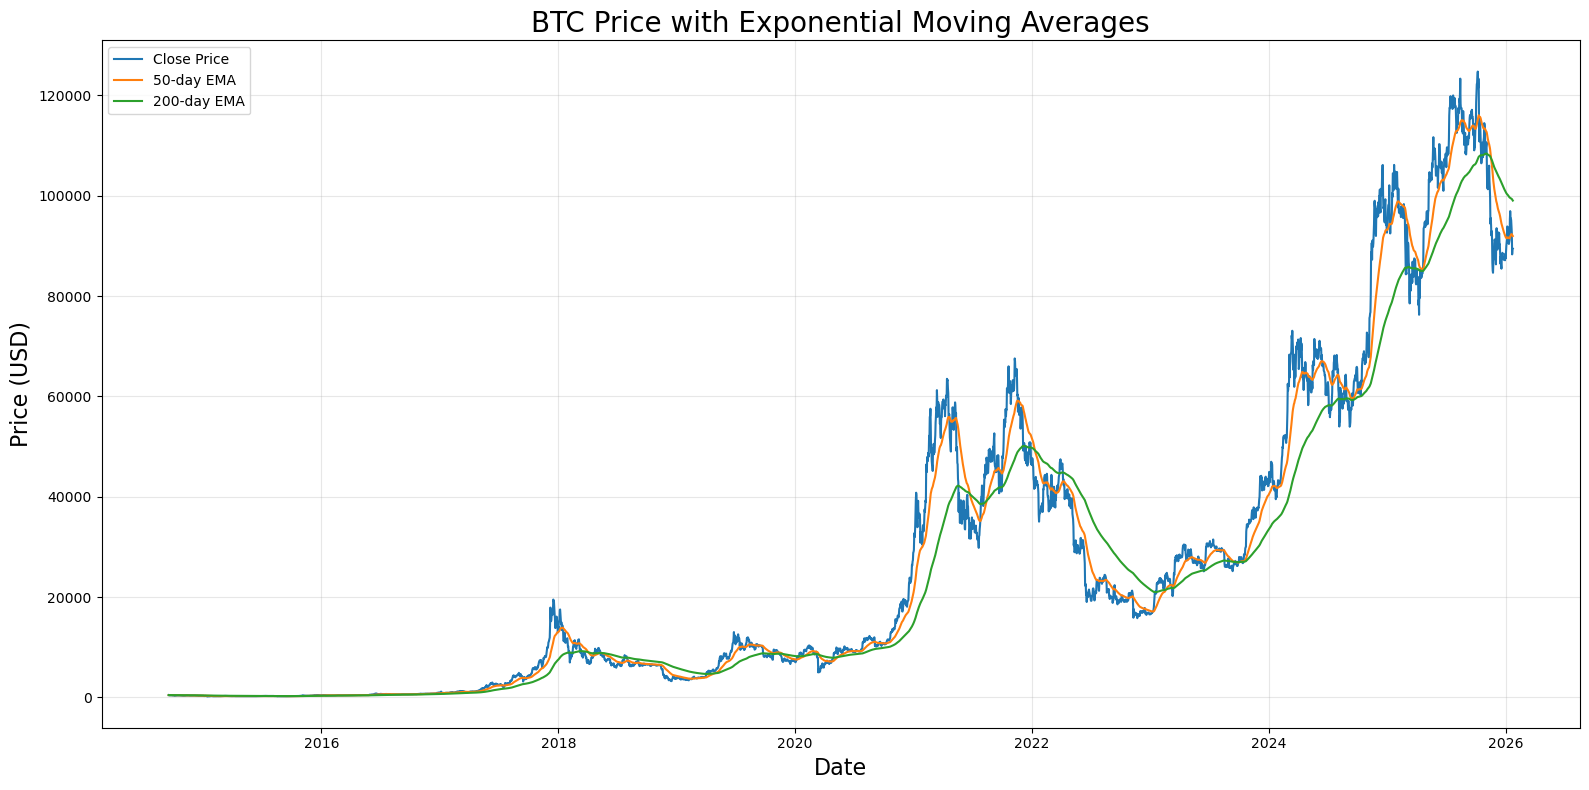

In [4]:
import matplotlib.pyplot as plt

# Add EMAs
df["EMA_50"] = df["Close"].ewm(span=50, adjust=False).mean()
df["EMA_200"] = df["Close"].ewm(span=200, adjust=False).mean()

plt.figure(figsize=(16,8))
plt.plot(df.index, df["Close"], label="Close Price")
plt.plot(df.index, df["EMA_50"], label="50-day EMA")
plt.plot(df.index, df["EMA_200"], label="200-day EMA")
plt.title("BTC Price with Exponential Moving Averages", fontsize=20)
plt.xlabel("Date", fontsize=16)
plt.ylabel("Price (USD)", fontsize=16)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


#### Calculating % Changed in each Trading Session


In [6]:
df['Percentage Change'] = df.Close.pct_change()
df[['Close', 'Percentage Change']]

Price,Close,Percentage Change
Ticker,BTC-USD,
Date,,
2014-09-17,457.334015,NaN
2014-09-18,424.440002,-0.071926
2014-09-19,394.795990,-0.069843
2014-09-20,408.903992,0.035735
2014-09-21,398.821014,-0.024659
...,...,...
2026-01-18,93634.429688,-0.015410
2026-01-19,92553.593750,-0.011543


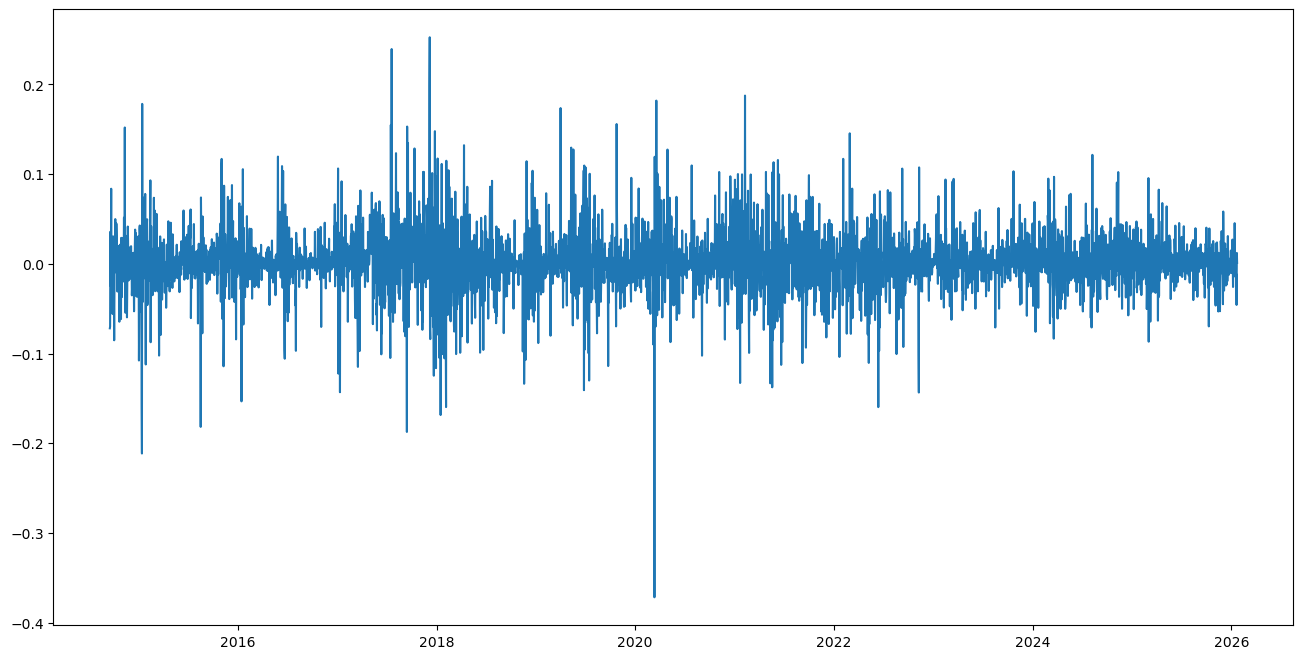

In [7]:
plt.figure(figsize=(16,8))
plt.plot(df['Percentage Change'])

### 4.Data Preprocessing

In [8]:
df.shape        

(4146, 8)

In [ ]:
# Splitting the data into training and testing sets
training_data = pd.DataFrame(df.Close[0:int(len(df)*0.70)])
testing_data = pd.DataFrame(df.Close[int(len(df)*0.70): int(len(df))])


print(training_data)
print(testing_data)

In [13]:
# Scaling down the data between 0 and 1

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))

training_data_array = scaler.fit_transform(training_data)
training_data_array

type(training_data_array)
training_data_array.shape

(2902, 1)

#### 5.Sequence Creation


In [18]:
x_train = []
y_train = []

for i in range(100, training_data_array.shape[0]):
    x_train.append(training_data_array[i-100: i])
    y_train.append(training_data_array[i, 0])
    
x_train, y_train = np.array(x_train), np.array(y_train)
x_train.shape, y_train.shape

((2802, 100, 1), (2802,))

#### 6.Model Building


In [19]:
import tensorflow as tf 
print(tf.__version__)

2.20.0


In [20]:
# ML Model
from keras.models import Sequential
from keras.layers import Dense, LSTM, Input

model = Sequential()

model.add(Input(shape=(100, 1)))
model.add(LSTM(units=128, activation='tanh', return_sequences=True))
model.add(LSTM(units=64))
model.add(Dense(units=1))


#### 7.Model Training

In [21]:
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(x_train, y_train, epochs=50)

Epoch 1/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 17s 131ms/step - loss: 0.0029
Epoch 2/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 11s 129ms/step - loss: 7.7658e-04
Epoch 3/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 11s 129ms/step - loss: 5.5010e-04
Epoch 4/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 10s 107ms/step - loss: 4.7749e-04
Epoch 5/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 10s 112ms/step - loss: 4.9817e-04
Epoch 6/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 10s 116ms/step - loss: 4.3436e-04
Epoch 7/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 10s 111ms/step - loss: 3.5880e-04
Epoch 8/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 10s 111ms/step - loss: 4.7053e-04
Epoch 9/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 10s 108ms/step - loss: 3.4415e-04
Epoch 10/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 10s 108ms/step - loss: 3.7991e-04
Epoch 11/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 10s 117ms/step - loss: 2.7627e-04
Epoch 12/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 20s 111ms/step - loss: 2.8567e-04
Epoch 13/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 11s 120ms/step - loss: 2.8017e-04
Epoch 14/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 10s 117ms/step - loss: 2.

In [22]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 128)       │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 348,101 (1.33 MB)

 Trainable params: 116,033 (453.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 232,068 (906.52 KB)

In [23]:
# Save the trained model
model.save("stock_prediction_model.keras")